In [1]:
import os
import copy
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

path = kagglehub.dataset_download("tongpython/cat-and-dog")
train_dir = os.path.join(path, "training_set", "training_set")
test_dir = os.path.join(path, "test_set", "test_set")

Using Colab cache for faster access to the 'cat-and-dog' dataset.


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [3]:
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs_max = 10
patience = 3
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
actual_epochs = 0

for epoch in range(epochs_max):
    actual_epochs += 1
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs_max} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Kích hoạt Early Stopping.")
        break

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_model.pth')

Epoch 1/10 - Train Loss: 0.1717, Train Acc: 0.9348 - Val Loss: 0.0945, Val Acc: 0.9664
Epoch 2/10 - Train Loss: 0.1037, Train Acc: 0.9597 - Val Loss: 0.0742, Val Acc: 0.9723
Epoch 3/10 - Train Loss: 0.1094, Train Acc: 0.9557 - Val Loss: 0.0653, Val Acc: 0.9773
Epoch 4/10 - Train Loss: 0.0903, Train Acc: 0.9619 - Val Loss: 0.0621, Val Acc: 0.9787
Epoch 5/10 - Train Loss: 0.0890, Train Acc: 0.9651 - Val Loss: 0.0638, Val Acc: 0.9763
Epoch 6/10 - Train Loss: 0.0844, Train Acc: 0.9664 - Val Loss: 0.0573, Val Acc: 0.9797
Epoch 7/10 - Train Loss: 0.0879, Train Acc: 0.9645 - Val Loss: 0.0580, Val Acc: 0.9778
Epoch 8/10 - Train Loss: 0.0832, Train Acc: 0.9686 - Val Loss: 0.0592, Val Acc: 0.9797
Epoch 9/10 - Train Loss: 0.0826, Train Acc: 0.9669 - Val Loss: 0.0581, Val Acc: 0.9763
Kích hoạt Early Stopping.


/tmp/ipykernel_13298/2023745456.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


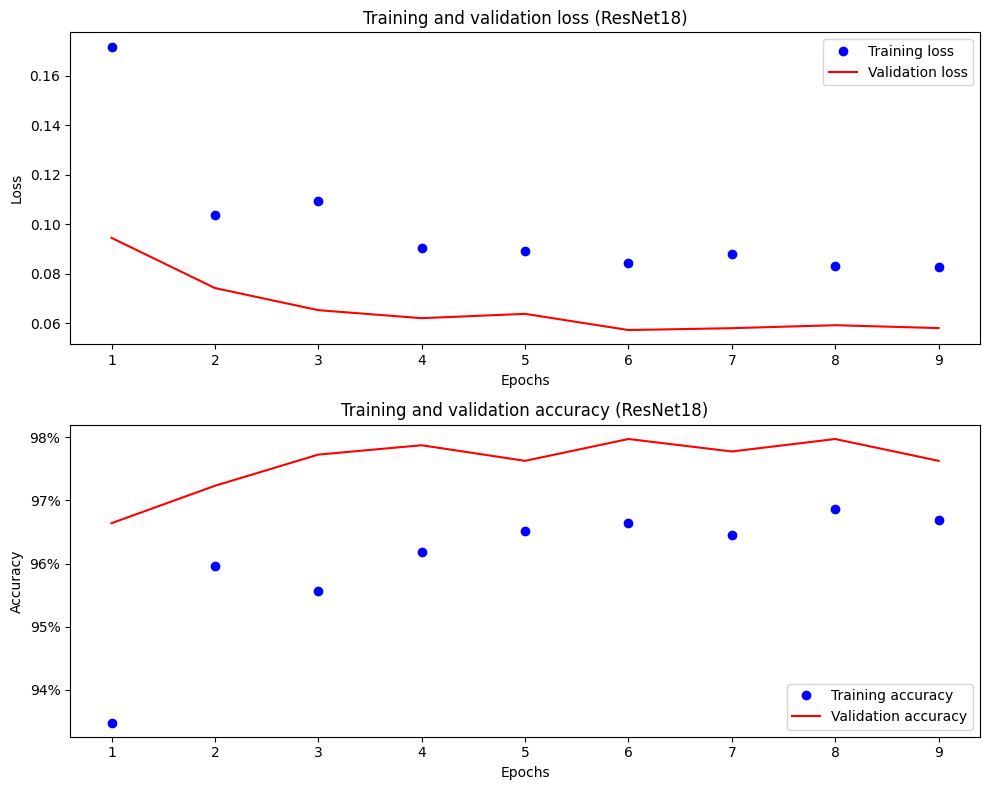

In [4]:
epochs_range = range(1, actual_epochs + 1)
plt.figure(figsize=(10, 8))

plt.subplot(211)
plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss (ResNet18)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(212)
plt.plot(epochs_range, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy (ResNet18)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
print("Accuracy Testing...")
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_acc = test_correct / test_total
print(f"Final Accuracy: {final_test_acc * 100:.2f}%")

Accuracy Testing...
Final Accuracy: 97.97%


Bắt đầu kiểm tra độ chính xác trên tập test...
Độ chính xác cuối cùng trên tập Test: 97.97%

Hiển thị trực quan một số kết quả dự đoán...


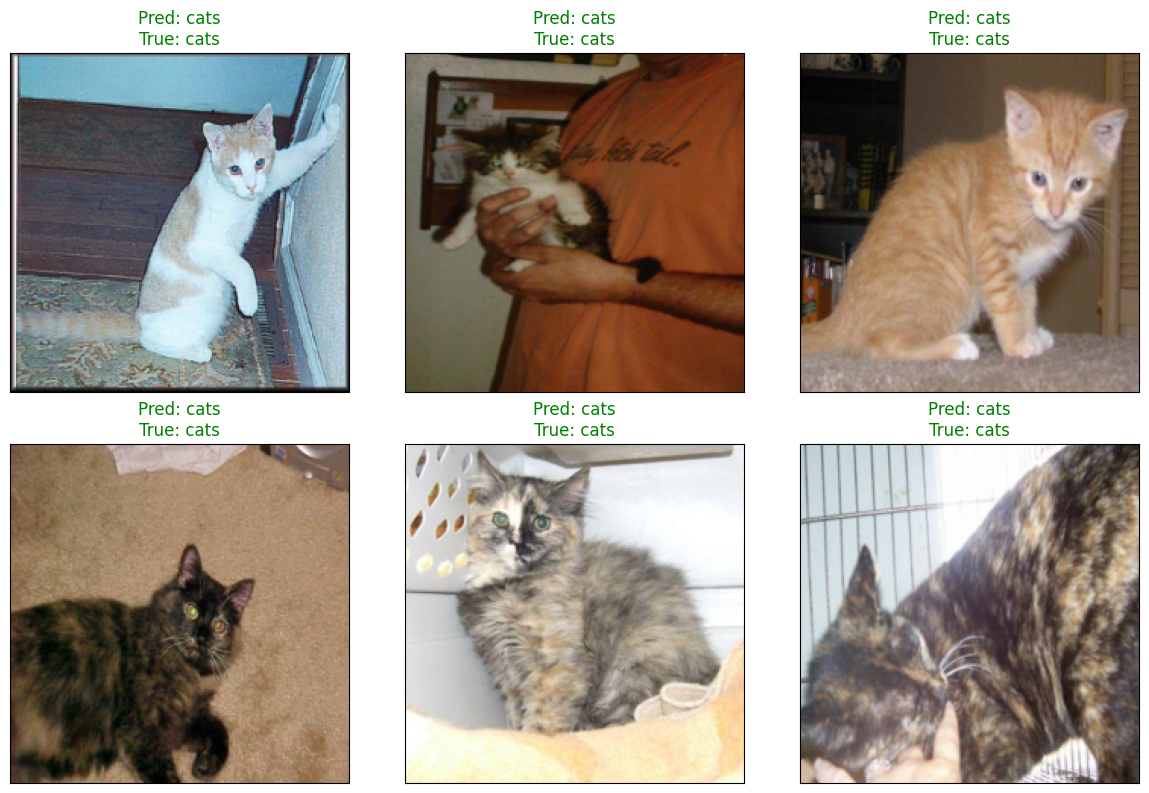

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Lấy danh sách tên các lớp (classes) từ test_data
classes = test_data.classes

print("Bắt đầu kiểm tra độ chính xác trên tập test...")
# Tải lại trọng số tốt nhất đã được lưu từ quá trình huấn luyện trước đó
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_correct = 0
test_total = 0

# Tính toán độ chính xác tổng thể trên toàn bộ tập test
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_acc = test_correct / test_total
print(f"Độ chính xác cuối cùng trên tập Test: {final_test_acc * 100:.2f}%\n")

print("Hiển thị trực quan một số kết quả dự đoán...")
# Lấy một batch hình ảnh ngẫu nhiên từ test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Dự đoán nhãn cho batch hình ảnh này
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Chuyển dữ liệu về CPU để vẽ đồ thị bằng matplotlib
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

fig = plt.figure(figsize=(12, 8))
# Hiển thị 6 hình ảnh đầu tiên trong batch
for idx in range(6):
    ax = fig.add_subplot(2, 3, idx+1, xticks=[], yticks=[])

    # Giải chuẩn hóa (un-normalize) hình ảnh để hiển thị đúng màu sắc gốc
    img = images[idx].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)

    # Lấy tên nhãn dự đoán và nhãn thực tế
    pred_label = classes[predicted[idx]]
    true_label = classes[labels[idx]]

    # Tô màu xanh nếu dự đoán đúng, đỏ nếu dự đoán sai
    color = "green" if predicted[idx] == labels[idx] else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)

plt.tight_layout()
plt.show()